In [1]:
!pip3 install segmentation-models-pytorch

    100% |################################| 102kB 2.1MB/s a 0:00:011
    100% |################################| 378kB 803kB/s eta 0:00:01
    100% |################################| 61kB 2.4MB/s eta 0:00:01
    100% |################################| 81kB 2.5MB/s eta 0:00:01
  Running setup.py bdist_wheel for pretrainedmodels ... done
  Stored in directory: /root/.cache/pip/wheels/69/df/63/62583c096289713f22db605aa2334de5b591d59861a02c2ecd
  Running setup.py bdist_wheel for efficientnet-pytorch ... done
  Stored in directory: /root/.cache/pip/wheels/84/27/aa/c46d23c4e8cc72d41283862b1437e0b3ad318417e8ed7d5921
Successfully built pretrainedmodels efficientnet-pytorch


In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from pathlib import Path
from PIL import Image
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset
import cv2
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.models.segmentation import fcn_resnet50
import torch.nn as nn
import segmentation_models_pytorch as smp
from tqdm import tqdm
import pandas as pd
import numpy as np
import time

from utils.lichen_dataset import LichenDataset


In [3]:
device = "cuda"

In [4]:
test_images = "/workspace/data_HITL/test/test_images"
test_masks = "/workspace/data_HITL/test/test_masks"

In [5]:
test_dataset = LichenDataset(
    image_dir=test_images,
    mask_dir=test_masks,
    image_size=512
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

Number of pairs found: 50


In [6]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

weights_path = "/workspace/weights_HITL/2unet_resnet34_lichen.pth"

state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [7]:
from pathlib import Path

p = Path("/workspace/weights_HITL/2unet_resnet34_lichen.pth")

print("exists:", p.exists())
print("size bytes:", p.stat().st_size if p.exists() else None)

exists: True
size bytes: 97923355


In [8]:
!head -20 /workspace/weights_HITL/2unet_resnet34_lichen.pth

PK                    2unet_resnet34_lichen/data.pklFB  �ccollections
OrderedDict
q )Rq(X   encoder.conv1.weightqctorch._utils
_rebuild_tensor_v2
q((X   storageqctorch
FloatStorage
qX   0qX   cuda:0qM�$tQK (K@KKKtq	(K�K1KKtq
X   encoder.bn1.weightqh((hhX   1qX   cuda:0qK@tqQK K@�qK�q�h )RqtqRqX   encoder.bn1.biasqh((hhX   2qX   cuda:0qK@tqQK K@�qK�q�h )RqtqRqX   encoder.bn1.running_meanq h((hhX   3q!X   cuda:0q"K@tq#QK K@�q$K�q%�h )Rq&tq'Rq(X   encoder.bn1.running_varq)h((hhX   4q*X   cuda:0q+K@tq,QK K@�q-K�q.�h )Rq/tq0Rq1X   encoder.bn1.num_batches_trackedq2h((hctorch
LongStorage
q3X   5q4X   cuda:0q5Ktq6QK ))�h )Rq7tq8Rq9X   encoder.layer1.0.conv1.weightq:h((hhX   6q;X   cuda:0q<M �tq=QK (K@K@KKtq>(M@K	KKtq?�h )Rq@tqARqBX   encoder.layer1.0.bn1.weightqCh((hhX   7qDX   cuda:0qEK@tqFQK K@�qGK�qH�h )RqItqJRqKX   encoder.layer1.0.bn1.biasqLh((hhX   8qMX   cuda:0qNK@tqOQK K@�qPK�qQ�h )RqRtqSR

In [9]:
def compute_metrics(pred, mask, eps=1e-7):
    pred = pred.bool()
    mask = mask.bool()

    tp = (pred & mask).sum().item()
    fp = (pred & ~mask).sum().item()
    fn = (~pred & mask).sum().item()
    tn = (~pred & ~mask).sum().item()

    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    accuracy = (tp + tn) / (tp + tn + fp + fn + eps)

    return {
        "iou": iou,
        "dice": dice,
        "precision": precision,
        "recall": recall,
        "accuracy": accuracy
    }

In [10]:
all_metrics = []
latencies = []

threshold = 0.5

with torch.no_grad():
    for images, masks, names in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        if device == "cuda":
            torch.cuda.synchronize()

        start = time.time()

        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = probs > threshold

        if device == "cuda":
            torch.cuda.synchronize()

        end = time.time()

        latency = end - start
        latencies.append(latency)

        metrics = compute_metrics(preds.cpu(), masks.cpu())
        metrics["filename"] = names[0]
        metrics["latency_sec"] = latency

        all_metrics.append(metrics)

/usr/local/lib/python3.6/dist-packages/torch/nn/functional.py:718: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at  /media/nvidia/NVME/pytorch/pytorch-v1.9.0/c10/core/TensorImpl.h:1156.)
  return torch.max_pool2d(input, kernel_size, stride, padding, dilation, ceil_mode)


In [11]:
df = pd.DataFrame(all_metrics)
df.head()

,iou,dice,precision,recall,accuracy,filename,latency_sec
0,0.647281,0.785878,0.661604,0.967637,0.834488,lichen_11032703,80.673636
1,0.626725,0.770536,0.888994,0.679935,0.757782,lichen_297012592,2.058166
2,0.808863,0.894333,0.879308,0.909880,0.830902,lichen_265585502,1.591047
3,0.122150,0.217706,0.135164,0.559200,0.670471,lichen_74735136,0.543719
4,0.604928,0.753838,0.818581,0.698587,0.816399,lichen_181096723,0.443502


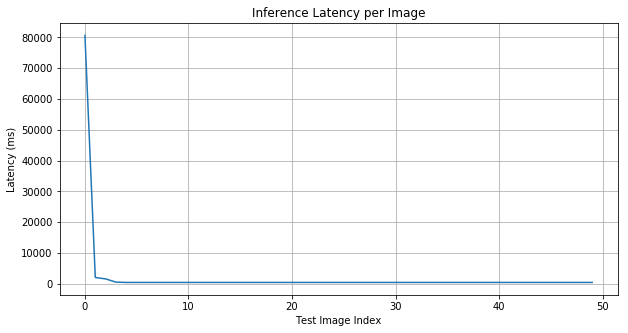

In [12]:
latencies_ms = [x * 1000 for x in latencies]

plt.figure(figsize=(10,5))

plt.plot(latencies_ms)

plt.xlabel("Test Image Index")
plt.ylabel("Latency (ms)")
plt.title("Inference Latency per Image")

plt.grid(True)

plt.show()

In [13]:
df.mean(numeric_only=True)

iou            0.583038
dice           0.709376
precision      0.706438
recall         0.789681
accuracy       0.829701
latency_sec    2.106674
dtype: float64

In [14]:
df

,iou,dice,precision,recall,accuracy,filename,latency_sec
0,0.647281,0.785878,0.661604,0.967637,0.834488,lichen_11032703,80.673636
1,0.626725,0.770536,0.888994,0.679935,0.757782,lichen_297012592,2.058166
2,0.808863,0.894333,0.879308,0.909880,0.830902,lichen_265585502,1.591047
3,0.122150,0.217706,0.135164,0.559200,0.670471,lichen_74735136,0.543719
4,0.604928,0.753838,0.818581,0.698587,0.816399,lichen_181096723,0.443502
5,0.398007,0.569392,0.632323,0.517853,0.870716,lichen_41813255,0.445034
6,0.791078,0.883354,0.800006,0.986090,0.914799,lichen_141767571,0.444308
7,0.426009,0.597484,0.860583,0.457589,0.705006,lichen_34608861,0.444633
8,0.541618,0.702662,0.585000,0.879571,0.824356,lichen_93036882,0.445305
9,0.865180,0.927717,0.911427,0.944601,0.922249,lichen_37456823,0.443477
